# 06 — Modeling (RQ4)

**Research question:** Which Spotify audio features are most strongly associated with a song charting on the Billboard Hot 100? Answered with two classifiers — Logistic Regression (direction + statistical strength) and Random Forest (non-linear structure, ranking validation).

**This is explanatory, not predictive analysis.** The goal is identifying which features have historically been associated with a Hit, not building a system to forecast future songs. The model pools six decades of data together, and musical trends shift over time — feature importance may not be stable across eras (see Limitations).

**Data source:** unlike the EDA stage, this notebook reads directly from `wrangled_D2.pkl` (Spotify Hit Predictor) rather than the three-way joined dataset — the Hit/Flop label and all 10 audio features live in D2 alone, and D2 is already a balanced 50/50 dataset, so no resampling is needed.

## Architecture

One dataset (D2), two models (LR, RF) evaluated through the *same* pipeline — that repeated evaluation logic is worth sharing rather than duplicating.

| CONFIG | | Engine (2 shared functions) | | Steps 1-15 |
|---|:---:|---|:---:|---|
| Data path, 10 feature columns, train/test split ratio, random seed, RF tree count | → | `build_modeling_dataset()` — selects columns, drops missing values, prints a composition report.<br>`evaluate_classifier()` — confusion matrix, accuracy, sensitivity/specificity, AUC, ROC; called once each for LR and RF | → | Part 1 (Steps 3-6): Logistic Regression<br>Part 2 (Steps 7-10): Random Forest<br>Part 3 (Steps 11-14): comparison + conclusion<br>Part 4 (Step 15): extended model |

**A reproducibility note up front:** train/test splitting uses a fixed random seed (42) so results are reproducible on re-run. The right validation standard for any metric here is *magnitude and direction* (RF beats LR, AUC lands in a reasonable 0.78-0.89 range, feature rankings make sense) rather than expecting bit-identical numbers on every environment.

## Step Blueprint

| Step | What it does | Question it answers | Data used | Who decides |
|---|---|---|---|---|
| 1 | Build modeling dataset | How many complete D2 rows are usable? Is Hit/Flop balanced? | Full dataset (pre-split) | Computed, human confirms |
| 1b | Feature correlation matrix | Are any of the 10 features redundant with each other? | Full dataset | Computed, human flags |
| 2 | Train/test split (80/20, stratified) | Does the split preserve the Hit ratio in both halves? | 80%/20% | Computed, human checks |
| 3 | LR — model construction | How do the 10 features combine to predict Hit/Flop? | 80% (train) | Computed |
| 4 | LR — coefficient table | Which features are statistically significant, and in which direction? | Step 3 output | Computed, human reads significance |
| 5 | LR — coefficient plot | Visualize magnitude and direction per feature | Step 4 output | Human reads chart |
| 6 | LR — model evaluation | How accurate is it on unseen data? | 20% (test) | Computed, human reads report |
| 7 | RF — model building | Does a model built for non-linear relationships do better? | 80% (train) | Computed |
| 8 | RF — feature importance (permutation + Gini) | Which features matter most? Does the ranking agree with LR? | 20% (test) | Computed, human reads ranking |
| 9 | RF — importance plot | Visualize the ranking | Step 8 output | Human reads chart |
| 10 | RF — model evaluation | Is RF actually more accurate than LR? | 20% (test) | Computed, human reads report |
| 11 | Performance comparison table | Who wins on accuracy, AUC, sensitivity, specificity? | Aggregated | Computed, human reads table |
| 12 | ROC curve comparison | Overlay both curves to compare discriminative power | Aggregated | Human reads chart |
| 13 | Feature importance comparison | Do both models agree on which features matter? | Aggregated | Human reads chart |
| 14 | Summary & limitations | Answer RQ4 directly; state what the analysis can't claim | Aggregated | Human judgment |
| 15 | Extended model: tech era + interaction terms | Does adding era controls and 3 feature-interaction terms meaningfully improve fit? | Fresh 80/20 split | Computed, human reads coefficients/R²/AUC |

> **Design note:** two-model comparison (LR + RF), 500 RF trees, 80/20 split, seed 42. RF importance uses test-set permutation importance (shuffle a feature, measure the accuracy drop on held-out data) — see Step 8.
>
> **Step 15** is an extension beyond the core 14-step comparison, added to test whether Pseudo R² (0.232 — these 10 features explain roughly 23% of what separates a Hit from a Flop) could be pushed further without new data collection.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, roc_auc_score, roc_curve
from sklearn.inspection import permutation_importance

# ============================================================
# CONFIG -- Only edit this section when changing dataset/features/split settings
# ============================================================
CONFIG = {
    "data_path": "../Data/wrangled_D2.pkl",
    "target_col": "target",
    "feature_cols": [
        "danceability", "energy", "loudness", "speechiness", "acousticness",
        "instrumentalness", "liveness", "valence", "tempo", "duration_ms",
    ],
    "test_size": 0.2,
    "random_state": 42,
    "rf_n_estimators": 500,
}

## Step 1 — Build Modeling Dataset

Selects the target column plus the 10 audio features from `wrangled_D2.pkl` and drops any row with a missing value. D2 was already balanced 50/50 (Hit/Flop) during cleaning, so no resampling is needed here — worth confirming directly, since this assumption is unusual for a classification problem.

In [2]:
# Select target + feature columns, drop rows with any missing values,
# print a composition health report.
def build_modeling_dataset(df, target_col, feature_cols):
    model_df = df[[target_col] + feature_cols].dropna().copy()
    model_df[target_col] = model_df[target_col].astype(int)

    n_hit = (model_df[target_col] == 1).sum()
    n_flop = (model_df[target_col] == 0).sum()
    print(f"Total Records:    {len(model_df):,}")
    print(f"Hit (1) Count:    {n_hit:,}")
    print(f"Flop (0) Count:   {n_flop:,}")
    print(f"Hit Percentage:   {round(n_hit / len(model_df) * 100, 2)}%")
    return model_df


print("[STEP 1] Build Modeling Dataset")
d2 = pd.read_pickle(CONFIG["data_path"])
model_df = build_modeling_dataset(d2, CONFIG["target_col"], CONFIG["feature_cols"])

[STEP 1] Build Modeling Dataset
Total Records:    41,106
Hit (1) Count:    20,553
Flop (0) Count:   20,553
Hit Percentage:   50.0%


## Step 1b — Feature Correlation Matrix

Before splitting or modeling, check pairwise Pearson correlation across the 10 audio features — a standard pre-modeling check for regression-family models, since highly correlated features can destabilize coefficient estimates (multicollinearity).

Rule of thumb: \|r\| < 0.7 is generally fine; 0.7-0.9 is a strong correlation worth flagging when interpreting coefficients; > 0.9 is close to duplicate information and a candidate for removal.

In [3]:
print("[STEP 1b] Feature Correlation Matrix (10x10)")

corr_matrix = model_df[CONFIG["feature_cols"]].corr()
print(corr_matrix.round(3).to_string())

# Flag any pair with |r| > 0.7 for special attention when interpreting coefficients
high_corr_pairs = []
for i, f1 in enumerate(CONFIG["feature_cols"]):
    for f2 in CONFIG["feature_cols"][i + 1:]:
        r = corr_matrix.loc[f1, f2]
        if abs(r) > 0.7:
            high_corr_pairs.append((f1, f2, round(r, 3)))

print("\nPairs with |r| > 0.7 (flagged for coefficient interpretation caution):")
for f1, f2, r in high_corr_pairs:
    print(f"  {f1} <-> {f2}: r = {r}")

[STEP 1b] Feature Correlation Matrix (10x10)
                  danceability  energy  loudness  speechiness  acousticness  instrumentalness  liveness  valence  tempo  duration_ms
danceability             1.000   0.206     0.274        0.156        -0.261            -0.302    -0.115    0.554 -0.067       -0.063
energy                   0.206   1.000     0.773        0.122        -0.715            -0.208     0.158    0.341  0.224        0.012
loudness                 0.274   0.773     1.000        0.069        -0.567            -0.374     0.087    0.272  0.169       -0.050
speechiness              0.156   0.122     0.069        1.000        -0.084            -0.084     0.131    0.002  0.037        0.008
acousticness            -0.261  -0.715    -0.567       -0.084         1.000             0.204    -0.031   -0.195 -0.180       -0.070
instrumentalness        -0.302  -0.208    -0.374       -0.084         0.204             1.000    -0.051   -0.287 -0.054        0.107
liveness                

[STEP 1b] Feature Correlation Heatmap


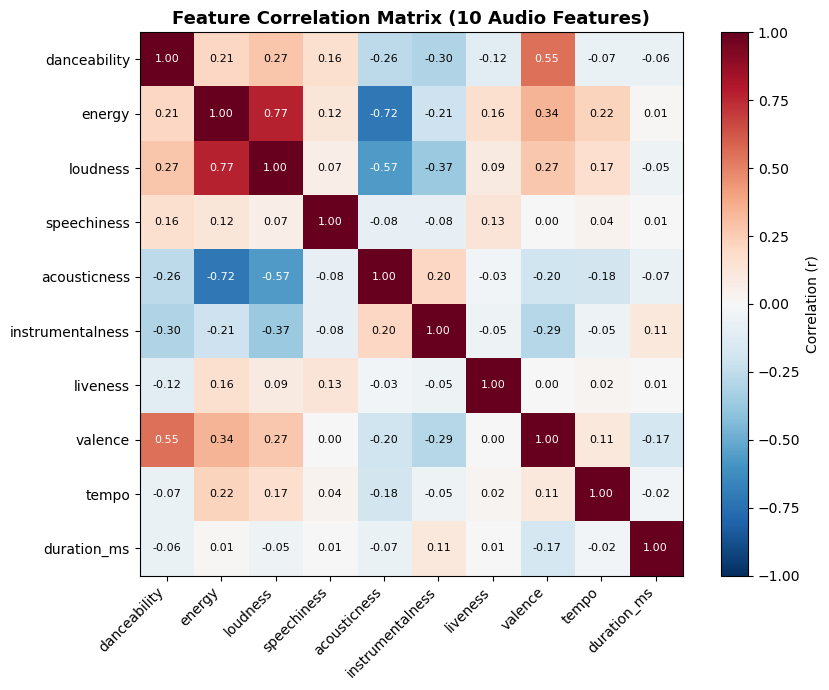

[SAVED] rq4_feature_correlation_heatmap.png


In [4]:
print("[STEP 1b] Feature Correlation Heatmap")

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_matrix, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(CONFIG["feature_cols"])))
ax.set_yticks(range(len(CONFIG["feature_cols"])))
ax.set_xticklabels(CONFIG["feature_cols"], rotation=45, ha="right")
ax.set_yticklabels(CONFIG["feature_cols"])
for i in range(len(CONFIG["feature_cols"])):
    for j in range(len(CONFIG["feature_cols"])):
        val = corr_matrix.iloc[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                color="white" if abs(val) > 0.5 else "black", fontsize=8)
plt.colorbar(im, ax=ax, label="Correlation (r)")
ax.set_title("Feature Correlation Matrix (10 Audio Features)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../Data/rq4_feature_correlation_heatmap.png", dpi=120)
plt.show()
print("[SAVED] rq4_feature_correlation_heatmap.png")

## Step 2 — Train / Test Split

80/20 stratified split (`stratify=target`) so the Hit ratio stays balanced in both halves rather than drifting from a plain random split.

In [5]:
print("[STEP 2] Train / Test Split (80/20, stratified)")

X = model_df[CONFIG["feature_cols"]]
y = model_df[CONFIG["target_col"]]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=CONFIG["test_size"],
    stratify=y,
    random_state=CONFIG["random_state"],
)

print(f"Train set size: {len(X_train):,}")
print(f"Test set size:  {len(X_test):,}\n")
print(f"Train set Hit ratio: {round((y_train == 1).mean() * 100, 2)}%")
print(f"Test set  Hit ratio: {round((y_test == 1).mean() * 100, 2)}%")

[STEP 2] Train / Test Split (80/20, stratified)
Train set size: 32,884
Test set size:  8,222

Train set Hit ratio: 50.0%
Test set  Hit ratio: 50.0%


## Part 1: Logistic Regression

### Step 3 — Model Construction

Uses `statsmodels.Logit`, not scikit-learn's `LogisticRegression` — `statsmodels` is the Python library that exposes full statistical-inference output (coefficient standard errors, z-values, p-values); scikit-learn's classifier only returns point-estimate coefficients, not their statistical significance.

In [6]:
print("[STEP 3] Logistic Regression -- Model Construction")

X_train_const = sm.add_constant(X_train, has_constant="add")
X_test_const = sm.add_constant(X_test, has_constant="add")

logit_model = sm.Logit(y_train, X_train_const).fit(disp=0)
print(logit_model.summary2().tables[0].to_string(index=False, header=False))

[STEP 3] Logistic Regression -- Model Construction
             Model:            Logit           Method:        MLE
Dependent Variable:           target Pseudo R-squared:      0.232
              Date: 2026-08-22 19:34              AIC: 35012.6295
  No. Observations:            32884              BIC: 35105.0377
          Df Model:               10   Log-Likelihood:    -17495.
      Df Residuals:            32873          LL-Null:    -22793.
         Converged:           1.0000      LLR p-value:     0.0000
    No. Iterations:           7.0000            Scale:     1.0000


### Step 4 — Coefficient Table (sorted by p-value)

One row per feature: coefficient, standard error, z-statistic, and p-value, plus two readability columns for significance and direction.

In [7]:
print("[STEP 4] Coefficient Table")

coef_df = pd.DataFrame({
    "term": logit_model.params.index,
    "estimate": logit_model.params.values,
    "std_error": logit_model.bse.values,
    "statistic": logit_model.tvalues.values,
    "p_value": logit_model.pvalues.values,
})
coef_df["significant"] = np.where(coef_df["p_value"] < 0.05, "Yes", "No")
coef_df["direction"] = np.where(coef_df["estimate"] > 0, "↑ Positive", "↓ Negative")
coef_df = coef_df.sort_values("p_value").reset_index(drop=True)

print(coef_df.round(4).to_string(index=False))

[STEP 4] Coefficient Table
            term  estimate  std_error  statistic  p_value significant  direction
instrumentalness   -3.3970     0.0751   -45.2425   0.0000         Yes ↓ Negative
    danceability    3.2848     0.1029    31.9335   0.0000         Yes ↑ Positive
    acousticness   -1.3949     0.0588   -23.7163   0.0000         Yes ↓ Negative
        loudness    0.1064     0.0049    21.7852   0.0000         Yes ↑ Positive
     speechiness   -3.4069     0.1747   -19.5019   0.0000         Yes ↓ Negative
          energy   -1.9282     0.1107   -17.4182   0.0000         Yes ↓ Negative
           const    1.3579     0.1381     9.8356   0.0000         Yes ↑ Positive
     duration_ms   -0.0000     0.0000    -6.8610   0.0000         Yes ↓ Negative
         valence    0.3209     0.0668     4.8010   0.0000         Yes ↑ Positive
           tempo    0.0019     0.0005     4.0318   0.0001         Yes ↑ Positive
        liveness   -0.1834     0.0773    -2.3722   0.0177         Yes ↓ Negative


### Step 5 — Feature Importance Visualization

Green = positive association, red = negative, transparent = not significant (p ≥ 0.05); error bars show the standard error. The intercept (`const`) is excluded.

[STEP 5] Logistic Regression -- Coefficient Plot


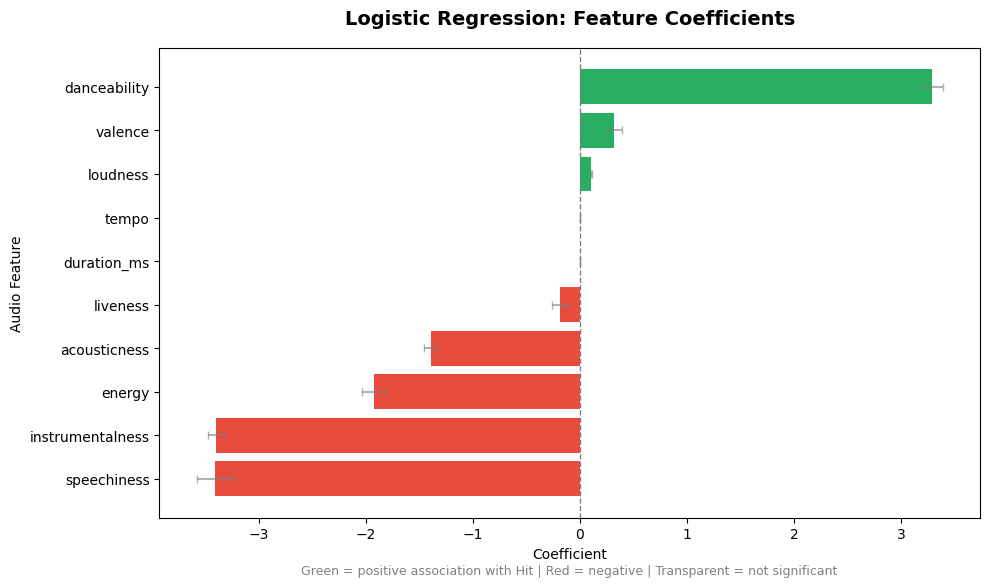

[SAVED] rq4_lr_coefficients.png


In [8]:
print("[STEP 5] Logistic Regression -- Coefficient Plot")

plot_df = coef_df[coef_df["term"] != "const"].copy()
plot_df["direction_label"] = np.where(plot_df["estimate"] > 0, "Positive", "Negative")
plot_df = plot_df.sort_values("estimate")

fig, ax = plt.subplots(figsize=(10, 6))
colors = plot_df["direction_label"].map({"Positive": "#27AE60", "Negative": "#E74C3C"})
alphas = np.where(plot_df["significant"] == "Yes", 1.0, 0.3)

bars = ax.barh(plot_df["term"], plot_df["estimate"], color=colors)
for bar, a in zip(bars, alphas):
    bar.set_alpha(a)
ax.errorbar(plot_df["estimate"], plot_df["term"], xerr=plot_df["std_error"],
            fmt="none", ecolor="gray", capsize=3, alpha=0.6)
ax.axvline(0, color="gray", linestyle="--", linewidth=1)

ax.set_xlabel("Coefficient")
ax.set_ylabel("Audio Feature")
ax.text(0.5, -0.12, "Green = positive association with Hit | Red = negative | Transparent = not significant",
        transform=ax.transAxes, ha="center", fontsize=9, color="gray")
plt.tight_layout(rect=[0, 0, 1, 0.93])

# Center the title over the plot box itself (not the whole canvas) -- the y-axis
# labels eat into the left margin, so figure-center and plot-center differ.
pos = ax.get_position()
fig.suptitle("Logistic Regression: Feature Coefficients", fontsize=14, fontweight="bold",
              y=0.97, x=(pos.x0 + pos.x1) / 2)
plt.savefig("../Data/rq4_lr_coefficients.png", dpi=120)
plt.show()
print('[SAVED] rq4_lr_coefficients.png')

### Step 6 — Model Evaluation

Evaluated on the held-out 20% test set: confusion matrix, accuracy, sensitivity (Hit recall), specificity (Flop recall), AUC. **This exact sequence is reused for Random Forest** via a shared `evaluate_classifier()` function rather than being duplicated.

[STEP 6] Logistic Regression -- Model Evaluation

Logistic Regression Evaluation

Confusion Matrix:
            Actual 0   Actual 1
Pred 0          2668        783
Pred 1          1443       3328

Accuracy:    0.7293
Sensitivity: 0.8095  (Hit recall)
Specificity: 0.6490  (Flop recall)
AUC:         0.8071


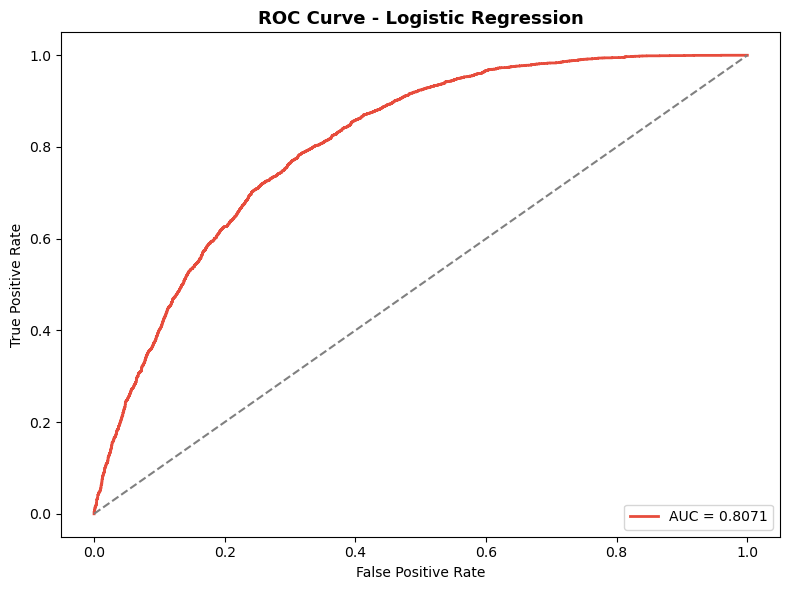

[SAVED] rq4_lr_roc.png


In [9]:
# Shared evaluation block for both LR and RF: confusion matrix, accuracy,
# sensitivity/specificity, AUC + ROC curve data -- extracted once since both
# models are evaluated with the exact same steps, not just similarly-shaped ones.
def evaluate_classifier(model_name, y_true, y_pred, y_prob):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    accuracy = accuracy_score(y_true, y_pred)
    sensitivity = recall_score(y_true, y_pred, pos_label=1)
    specificity = recall_score(y_true, y_pred, pos_label=0)
    auc_val = roc_auc_score(y_true, y_prob)
    fpr, tpr, _ = roc_curve(y_true, y_prob)

    print(f"\n{'=' * 40}")
    print(f"{model_name} Evaluation")
    print(f"{'=' * 40}\n")
    print("Confusion Matrix:")
    print(f"{'':<12}Actual 0   Actual 1")
    print(f"{'Pred 0':<12}{tn:>8}   {fn:>8}")
    print(f"{'Pred 1':<12}{fp:>8}   {tp:>8}\n")
    print(f"Accuracy:    {accuracy:.4f}")
    print(f"Sensitivity: {sensitivity:.4f}  (Hit recall)")
    print(f"Specificity: {specificity:.4f}  (Flop recall)")
    print(f"AUC:         {auc_val:.4f}")

    return {"model": model_name, "accuracy": accuracy, "sensitivity": sensitivity,
            "specificity": specificity, "auc": auc_val, "fpr": fpr, "tpr": tpr}


print("[STEP 6] Logistic Regression -- Model Evaluation")

lr_pred_prob = logit_model.predict(X_test_const)
lr_pred_class = (lr_pred_prob > 0.5).astype(int)
lr_results = evaluate_classifier("Logistic Regression", y_test, lr_pred_class, lr_pred_prob)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(lr_results["fpr"], lr_results["tpr"], color="#E74C3C", linewidth=2,
        label=f"AUC = {lr_results['auc']:.4f}")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
ax.set_title("ROC Curve - Logistic Regression", fontsize=13, fontweight="bold")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../Data/rq4_lr_roc.png", dpi=120)
plt.show()
print("[SAVED] rq4_lr_roc.png")

## Part 2: Random Forest

### Step 7 — Model Building

500 trees, `random_state=42` for reproducibility. scikit-learn's default `max_features="sqrt"` (floor(sqrt(10)) = 3 features considered per split) is the standard setting for classification random forests.

In [10]:
print("[STEP 7] Random Forest -- Model Building")

rf_model = RandomForestClassifier(
    n_estimators=CONFIG["rf_n_estimators"],
    random_state=CONFIG["random_state"],
)
rf_model.fit(X_train, y_train)

print(f"Number of trees: {rf_model.n_estimators}")
print(f"Features per split (max_features): {rf_model.max_features}")
print(f"OOB available: {rf_model.oob_score}")

[STEP 7] Random Forest -- Model Building


Number of trees: 500
Features per split (max_features): sqrt
OOB available: False


### Step 8 — Feature Importance

**Methodology note:** `sklearn.inspection.permutation_importance()` measures a feature's real contribution to accuracy by shuffling it and checking how much accuracy drops on the **test set** (data the model never trained on) — the standard scikit-learn approach for measuring genuine predictive contribution rather than in-sample fit.

`feature_importances_` (scikit-learn's built-in Gini/impurity-based importance) is also kept — a second, faster-to-compute importance measure based on how much each feature reduces impurity across the tree splits it's used in.

In [11]:
print("[STEP 8] Random Forest -- Feature Importance")

perm = permutation_importance(
    rf_model, X_test, y_test,
    n_repeats=10, random_state=CONFIG["random_state"], n_jobs=-1,
)

importance_df = pd.DataFrame({
    "feature": CONFIG["feature_cols"],
    "MeanDecreaseAccuracy": perm.importances_mean,
    "MeanDecreaseGini": rf_model.feature_importances_,
}).sort_values("MeanDecreaseAccuracy", ascending=False).reset_index(drop=True)

print("Feature Importance Ranking:\n")
print(importance_df.round(4).to_string(index=False))

[STEP 8] Random Forest -- Feature Importance


Feature Importance Ranking:

         feature  MeanDecreaseAccuracy  MeanDecreaseGini
instrumentalness                0.0978            0.1876
    acousticness                0.0647            0.1285
    danceability                0.0384            0.1172
     duration_ms                0.0275            0.0914
        loudness                0.0250            0.0865
     speechiness                0.0188            0.0868
          energy                0.0166            0.0926
         valence                0.0099            0.0802
           tempo                0.0050            0.0671
        liveness                0.0019            0.0621


### Step 9 — Feature Importance Visualization

Sorted by `MeanDecreaseAccuracy` — a longer bar means shuffling that feature hurts accuracy more, i.e. the model relies on it more.

[STEP 9] Random Forest -- Feature Importance Plot


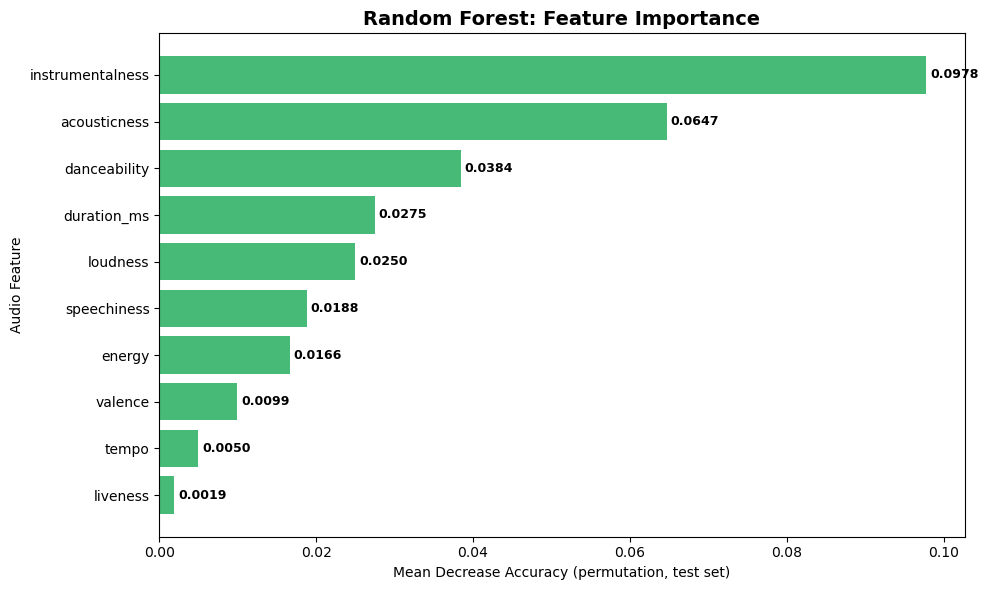

[SAVED] rq4_rf_importance.png


In [12]:
print("[STEP 9] Random Forest -- Feature Importance Plot")

plot_imp = importance_df.sort_values("MeanDecreaseAccuracy")

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(plot_imp["feature"], plot_imp["MeanDecreaseAccuracy"], color="#27AE60", alpha=0.85)
for bar, val in zip(bars, plot_imp["MeanDecreaseAccuracy"]):
    ax.text(bar.get_width() + 0.0005, bar.get_y() + bar.get_height() / 2, f"{val:.4f}",
            va="center", fontsize=9, fontweight="bold")
ax.set_title("Random Forest: Feature Importance", fontsize=14, fontweight="bold")
ax.set_xlabel("Mean Decrease Accuracy (permutation, test set)")
ax.set_ylabel("Audio Feature")
plt.tight_layout()
plt.savefig("../Data/rq4_rf_importance.png", dpi=120)
plt.show()
print("[SAVED] rq4_rf_importance.png")

### Step 10 — Model Evaluation

Same `evaluate_classifier()` as Step 6, reused rather than re-implemented.

[STEP 10] Random Forest -- Model Evaluation



Random Forest Evaluation

Confusion Matrix:
            Actual 0   Actual 1
Pred 0          3024        687
Pred 1          1087       3424

Accuracy:    0.7842
Sensitivity: 0.8329  (Hit recall)
Specificity: 0.7356  (Flop recall)
AUC:         0.8666


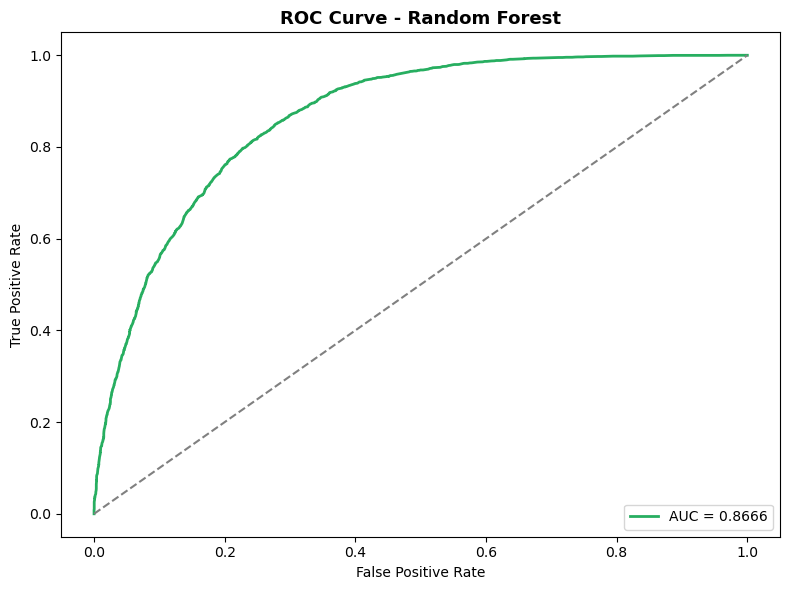

[SAVED] rq4_rf_roc.png


In [13]:
print("[STEP 10] Random Forest -- Model Evaluation")

rf_pred_class = rf_model.predict(X_test)
rf_pred_prob = rf_model.predict_proba(X_test)[:, 1]
rf_results = evaluate_classifier("Random Forest", y_test, rf_pred_class, rf_pred_prob)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(rf_results["fpr"], rf_results["tpr"], color="#27AE60", linewidth=2,
        label=f"AUC = {rf_results['auc']:.4f}")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
ax.set_title("ROC Curve - Random Forest", fontsize=13, fontweight="bold")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../Data/rq4_rf_roc.png", dpi=120)
plt.show()
print("[SAVED] rq4_rf_roc.png")

## Part 3: Model Comparison

### Step 11 — Performance Comparison Table

In [14]:
print("[STEP 11] Model Performance Comparison")

comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [lr_results["accuracy"], rf_results["accuracy"]],
    "AUC": [lr_results["auc"], rf_results["auc"]],
    "Sensitivity": [lr_results["sensitivity"], rf_results["sensitivity"]],
    "Specificity": [lr_results["specificity"], rf_results["specificity"]],
}).round(4)

print(comparison_df.to_string(index=False))

[STEP 11] Model Performance Comparison
              Model  Accuracy    AUC  Sensitivity  Specificity
Logistic Regression    0.7293 0.8071       0.8095       0.6490
      Random Forest    0.7842 0.8666       0.8329       0.7356


### Step 12 — ROC Curve Comparison

Both ROC curves on one chart for a direct visual comparison of discriminative power.

[STEP 12] ROC Curve Comparison


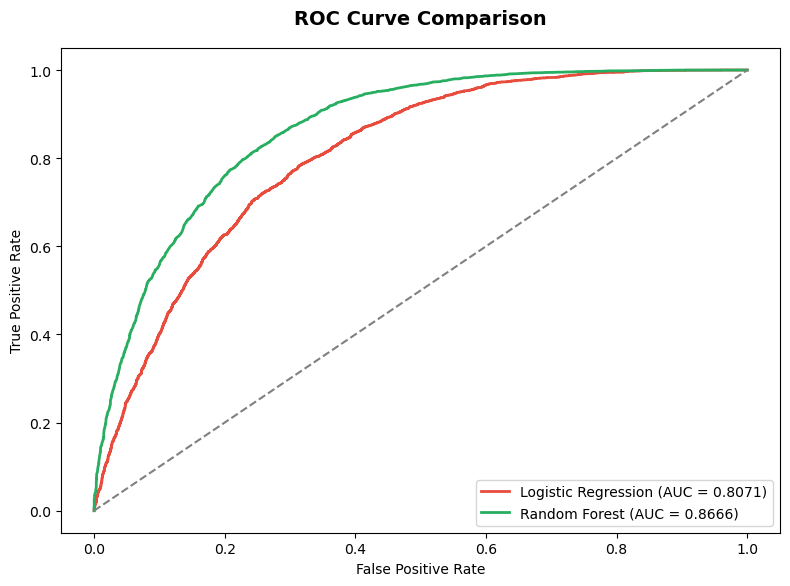

[SAVED] rq4_roc_comparison.png


In [15]:
print("[STEP 12] ROC Curve Comparison")

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(lr_results["fpr"], lr_results["tpr"], color="#E74C3C", linewidth=2,
        label=f"Logistic Regression (AUC = {lr_results['auc']:.4f})")
ax.plot(rf_results["fpr"], rf_results["tpr"], color="#27AE60", linewidth=2,
        label=f"Random Forest (AUC = {rf_results['auc']:.4f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")
plt.tight_layout(rect=[0, 0, 1, 0.93])

pos = ax.get_position()
fig.suptitle("ROC Curve Comparison", fontsize=14, fontweight="bold",
              y=0.97, x=(pos.x0 + pos.x1) / 2)
plt.savefig("../Data/rq4_roc_comparison.png", dpi=120)
plt.show()
print('[SAVED] rq4_roc_comparison.png')

### Step 13 — Feature Importance Comparison

The two models compute importance differently (LR: absolute coefficient value; RF: permutation importance) — each is scaled to 0-1 independently before being placed on the same chart.

[STEP 13] Feature Importance Comparison


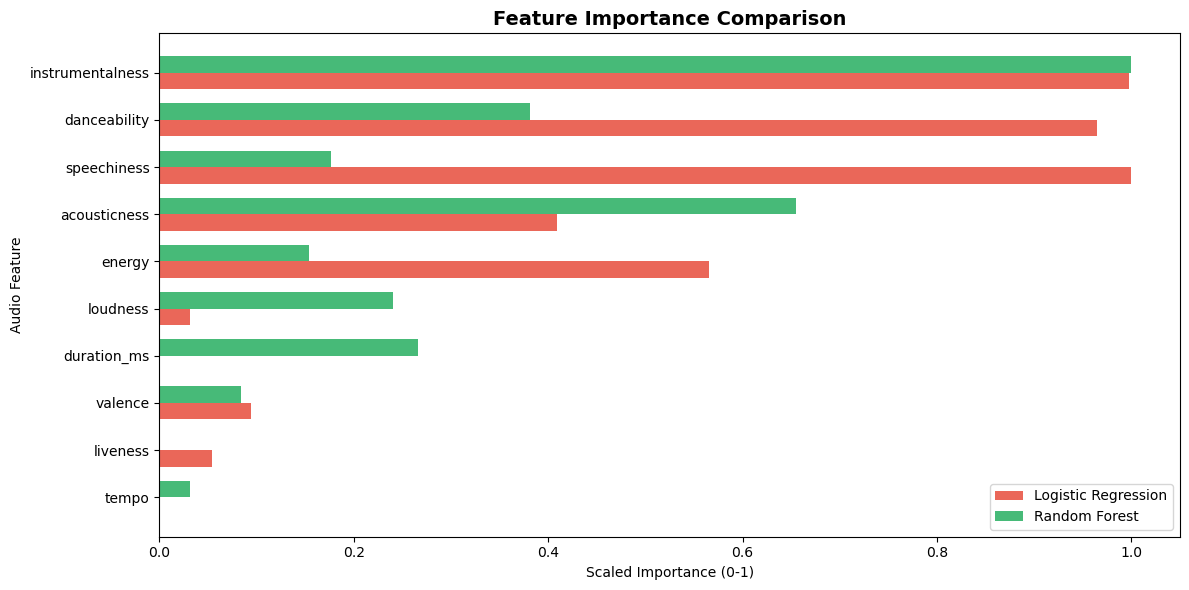

[SAVED] rq4_importance_comparison.png


In [16]:
print("[STEP 13] Feature Importance Comparison")

lr_imp = coef_df[coef_df["term"] != "const"].copy()
lr_imp["feature"] = lr_imp["term"]
lr_imp["importance"] = lr_imp["estimate"].abs()
lr_imp["importance_scaled"] = (lr_imp["importance"] - lr_imp["importance"].min()) / \
                               (lr_imp["importance"].max() - lr_imp["importance"].min())
lr_imp["model"] = "Logistic Regression"
lr_imp = lr_imp[["feature", "importance_scaled", "model"]]

rf_imp = importance_df.copy()
rf_imp["importance"] = rf_imp["MeanDecreaseAccuracy"]
rf_imp["importance_scaled"] = (rf_imp["importance"] - rf_imp["importance"].min()) / \
                               (rf_imp["importance"].max() - rf_imp["importance"].min())
rf_imp["model"] = "Random Forest"
rf_imp = rf_imp[["feature", "importance_scaled", "model"]]

combined_importance = pd.concat([lr_imp, rf_imp], ignore_index=True)
feature_order = (
    combined_importance.groupby("feature")["importance_scaled"].mean()
    .sort_values().index.tolist()
)

pivot_imp = combined_importance.pivot(index="feature", columns="model", values="importance_scaled").reindex(feature_order)

fig, ax = plt.subplots(figsize=(12, 6))
y = range(len(pivot_imp.index))
height = 0.35
ax.barh([i - height / 2 for i in y], pivot_imp["Logistic Regression"], height,
        label="Logistic Regression", color="#E74C3C", alpha=0.85)
ax.barh([i + height / 2 for i in y], pivot_imp["Random Forest"], height,
        label="Random Forest", color="#27AE60", alpha=0.85)
ax.set_yticks(list(y))
ax.set_yticklabels(pivot_imp.index)
ax.set_title("Feature Importance Comparison", fontsize=14, fontweight="bold")
ax.set_xlabel("Scaled Importance (0-1)")
ax.set_ylabel("Audio Feature")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../Data/rq4_importance_comparison.png", dpi=120)
plt.show()
print("[SAVED] rq4_importance_comparison.png")

### Step 14 — Summary & Limitations

Answers RQ4 directly. The numbers below are read live from this notebook's own run each time it executes.

In [17]:
print("[STEP 14] Final Summary & Limitations")

better_model = "Random Forest" if rf_results["auc"] > lr_results["auc"] else "Logistic Regression"
top_lr_features = lr_imp.sort_values("importance_scaled", ascending=False)["feature"].head(4).tolist()
top_rf_features = rf_imp.sort_values("importance_scaled", ascending=False)["feature"].head(4).tolist()

print("=" * 60)
print("Research Question: Which audio features are most strongly")
print("associated with a song's chart performance?")
print("=" * 60)

print(f"\nModel Performance Summary")
print(f"  Logistic Regression : Accuracy = {lr_results['accuracy']:.4f} | AUC = {lr_results['auc']:.4f}")
print(f"  Random Forest        : Accuracy = {rf_results['accuracy']:.4f} | AUC = {rf_results['auc']:.4f}")

print(f"\nKey Findings")
print(f"  1. Model superiority: {better_model} achieved the higher AUC in this run,")
print(f"     suggesting non-linear relationships exist between audio features and chart")
print(f"     success that Logistic Regression's linear decision boundary can't fully capture.")
print(f"  2. Top LR features (by |scaled coefficient|): {', '.join(top_lr_features)}")
print(f"     Top RF features (by scaled permutation importance): {', '.join(top_rf_features)}")
print(f"  3. AUC of {rf_results['auc']:.2f} (Random Forest) indicates meaningful but incomplete")
print(f"     discriminative power -- a large share of variance remains unexplained by")
print(f"     audio features alone (marketing, artist reputation, timing, etc.).")

print(f"\nAnalysis Limitations")
print("  - Temporal Bias: six decades pooled into one model; feature-hit relationships")
print("    may shift by era (a decade-specific model is future work, not done here).")
print("  - Label Definition: hit/flop is defined by the dataset author, and may not")
print("    perfectly align with official Billboard chart placement.")
print("  - Missing Variables: non-musical factors (marketing budget, social media reach,")
print("    artist fame) are not in this dataset and are not modeled.")
print("  - Genre Bias: audio feature distributions vary by genre; this may affect how")
print("    fairly the model generalizes across genres.")
print("  - RF importance methodology: MeanDecreaseAccuracy here is computed via test-set")
print("    permutation importance rather than out-of-bag permutation importance (see Step 8).")


[STEP 14] Final Summary & Limitations
Research Question: Which audio features are most strongly
associated with a song's chart performance?

Model Performance Summary
  Logistic Regression : Accuracy = 0.7293 | AUC = 0.8071
  Random Forest        : Accuracy = 0.7842 | AUC = 0.8666

Key Findings
  1. Model superiority: Random Forest achieved the higher AUC in this run,
     suggesting non-linear relationships exist between audio features and chart
     success that Logistic Regression's linear decision boundary can't fully capture.
  2. Top LR features (by |scaled coefficient|): speechiness, instrumentalness, danceability, energy
     Top RF features (by scaled permutation importance): instrumentalness, acousticness, danceability, duration_ms
  3. AUC of 0.87 (Random Forest) indicates meaningful but incomplete
     discriminative power -- a large share of variance remains unexplained by
     audio features alone (marketing, artist reputation, timing, etc.).

Analysis Limitations
  - Tem

## Part 4: Extended Model

### Step 15 — Technology Era + Interaction Terms

**Motivation:** Step 14 closes with Pseudo R² = 0.232 — these 10 features explain roughly 23% of what separates a Hit from a Flop. Two extensions were tested together as one combined model, run through the full Step 3-6 pipeline rather than just checking whether R² moves:

1. **Technology era** (`era_digital_download`, `era_streaming`, reference category `pre_digital`) — controls for the known "six decades pooled together" limitation. D2 only has decade-level dates, so era is approximated in three bands.
2. **Interaction terms** (`dance_x_energy`, `instrumental_x_acoustic`, `dance_x_valence`) — Step 11 already showed RF (AUC 0.87) beating LR (AUC 0.80) by a wide margin, suggesting a non-linear/combination effect LR's additive formula can't represent on its own. Three musically-plausible feature products are tested.

**Why interaction terms, specifically:** LR's formula (intercept + weight × feature, summed) can only draw a straight line per feature — it has no way to represent "feature A matters more when feature B is also high." RF's tree-vote structure can capture that kind of combination effect natively. Multiplying two features into a new column is the standard way to let a linear model test for it explicitly.

**Why these three pairs, not others:** (1) each term pairs features that already rank highly individually in Steps 4 and 8, giving the interaction a better chance of reflecting a real signal rather than noise; (2) each has a plausible musical rationale — `dance_x_energy` (the classic upbeat dance-track combination), `instrumental_x_acoustic` (two already-negative features, testing whether they compound), `dance_x_valence` (danceable + upbeat, a common "earworm" formula); (3) pairs already flagged as highly correlated in Step 1b (e.g. `energy`/`loudness` at 0.773) are deliberately avoided, since interacting already-redundant features would only worsen multicollinearity.

15 features total (10 original + 2 era dummies + 3 interaction terms), run through the complete pipeline: model → coefficient table → coefficient plot → test-set evaluation (confusion matrix, accuracy, sensitivity, specificity, AUC, ROC) — same format as Steps 3-6, for direct comparison.

In [18]:
print("[STEP 15a] Build Extended Dataset (Tech Era + Interaction Terms)")

decade_to_era = {
    "60s": "pre_digital", "70s": "pre_digital", "80s": "pre_digital",
    "90s": "digital_download", "00s": "digital_download",
    "10s": "streaming",
}

model_df_ext = d2[["target"] + CONFIG["feature_cols"] + ["decade"]].dropna().copy()
model_df_ext["target"] = model_df_ext["target"].astype(int)

# pd.Categorical with an explicit category order guarantees "pre_digital" is
# the reference category after drop_first=True.
model_df_ext["tech_era"] = pd.Categorical(
    model_df_ext["decade"].astype(str).map(decade_to_era),
    categories=["pre_digital", "digital_download", "streaming"],
)
era_dummies = pd.get_dummies(model_df_ext["tech_era"], prefix="era", drop_first=True).astype(int)
model_df_ext = pd.concat([model_df_ext, era_dummies], axis=1)

model_df_ext["dance_x_energy"] = model_df_ext["danceability"] * model_df_ext["energy"]
model_df_ext["instrumental_x_acoustic"] = model_df_ext["instrumentalness"] * model_df_ext["acousticness"]
model_df_ext["dance_x_valence"] = model_df_ext["danceability"] * model_df_ext["valence"]

interaction_cols = ["dance_x_energy", "instrumental_x_acoustic", "dance_x_valence"]
extended_feature_cols = CONFIG["feature_cols"] + list(era_dummies.columns) + interaction_cols

print(f"Tech era distribution:\n{model_df_ext['tech_era'].value_counts().to_string()}")
print(f"\nExtended feature set ({len(extended_feature_cols)} features):")
print(extended_feature_cols)

[STEP 15a] Build Extended Dataset (Tech Era + Interaction Terms)
Tech era distribution:
tech_era
pre_digital         23316
digital_download    11392
streaming            6398

Extended feature set (15 features):
['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'era_digital_download', 'era_streaming', 'dance_x_energy', 'instrumental_x_acoustic', 'dance_x_valence']


### Step 15a-2 — Tech Era vs. the Original 10 Features

Before adding technology era to the model, check whether it substantially overlaps with any existing feature (same \|r\| > 0.7 threshold as Step 1b) — if era were nearly identical to an existing feature, adding it would contribute little.

In [19]:
print("[STEP 15a-2] Correlation Check: Tech Era vs. Original 10 Features")

corr_check = model_df_ext[CONFIG["feature_cols"] + list(era_dummies.columns)].corr()
era_vs_features = corr_check.loc[CONFIG["feature_cols"], list(era_dummies.columns)]

print(era_vs_features.round(3).to_string())

high_corr = era_vs_features[era_vs_features.abs() > 0.7].stack()
if len(high_corr) == 0:
    print("\nNo |r| > 0.7 pairs -- tech era is not redundant with the existing 10 features.")
else:
    print(f"\nFlagged pairs (|r| > 0.7):\n{high_corr}")

[STEP 15a-2] Correlation Check: Tech Era vs. Original 10 Features
                  era_digital_download  era_streaming
danceability                     0.052          0.069
energy                           0.172          0.150
loudness                         0.166          0.213
speechiness                      0.076          0.125
acousticness                    -0.206         -0.187
instrumentalness                 0.002          0.015
liveness                        -0.017         -0.012
valence                         -0.077         -0.159
tempo                            0.020          0.044
duration_ms                      0.116          0.007

No |r| > 0.7 pairs -- tech era is not redundant with the existing 10 features.


[STEP 15a-3] Correlation Heatmap: Tech Era vs. Original 10 Features


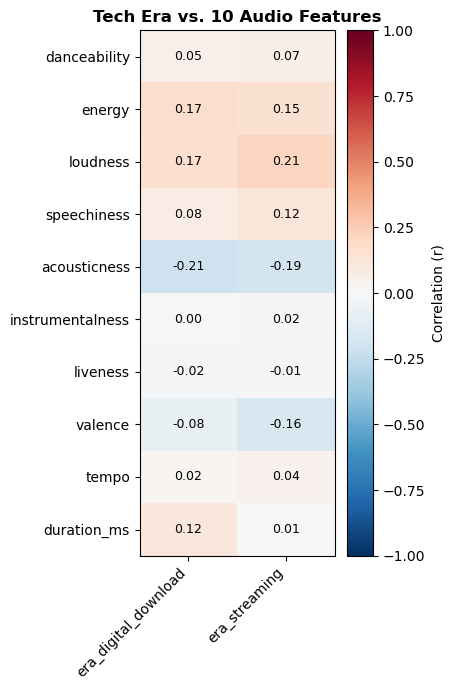

[SAVED] rq4_era_correlation_heatmap.png

Note: 'pre_digital' has no column of its own -- it is the reference
category (era_digital_download=0 AND era_streaming=0), same dummy-
variable logic as the const column's baseline role in Step 3.


In [20]:
print("[STEP 15a-3] Correlation Heatmap: Tech Era vs. Original 10 Features")

fig, ax = plt.subplots(figsize=(4.5, 7))
im = ax.imshow(era_vs_features, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(era_vs_features.columns)))
ax.set_yticks(range(len(era_vs_features.index)))
ax.set_xticklabels(era_vs_features.columns, rotation=45, ha="right")
ax.set_yticklabels(era_vs_features.index)
for i in range(len(era_vs_features.index)):
    for j in range(len(era_vs_features.columns)):
        val = era_vs_features.iloc[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                color="white" if abs(val) > 0.5 else "black", fontsize=9)
plt.colorbar(im, ax=ax, label="Correlation (r)")
ax.set_title("Tech Era vs. 10 Audio Features", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("../Data/rq4_era_correlation_heatmap.png", dpi=120)
plt.show()
print("[SAVED] rq4_era_correlation_heatmap.png")
print()
print("Note: 'pre_digital' has no column of its own -- it is the reference")
print("category (era_digital_download=0 AND era_streaming=0), same dummy-")
print("variable logic as the const column's baseline role in Step 3.")

**Verified result:** every pairing comes in under \|r\| < 0.7 — technology era carries information independent of the existing 10 features, and is worth adding. The direction of each correlation also lines up with the RQ2 EDA findings rather than appearing out of nowhere: `loudness` rises with digitization (the "loudness war"), `acousticness` falls (the shift toward electronic production), `valence` is most negative in the streaming era (matching RQ2's lowest-valence period), and `energy` rises with both eras — consistent, cross-checked signal from the same underlying data, not a coincidence.

In [21]:
print("[STEP 15b] Train / Test Split (Extended Feature Set, 80/20, stratified)")

X_ext = model_df_ext[extended_feature_cols]
y_ext = model_df_ext["target"]

X_train_ext, X_test_ext, y_train_ext, y_test_ext = train_test_split(
    X_ext, y_ext,
    test_size=CONFIG["test_size"],
    stratify=y_ext,
    random_state=CONFIG["random_state"],
)

print(f"Train set size: {len(X_train_ext):,}")
print(f"Test set size:  {len(X_test_ext):,}")

[STEP 15b] Train / Test Split (Extended Feature Set, 80/20, stratified)
Train set size: 32,884
Test set size:  8,222


In [22]:
print("[STEP 15c] Logistic Regression -- Extended Model Construction")

X_train_ext_const = sm.add_constant(X_train_ext, has_constant="add")
X_test_ext_const = sm.add_constant(X_test_ext, has_constant="add")

logit_model_ext = sm.Logit(y_train_ext, X_train_ext_const).fit(disp=0)
print(logit_model_ext.summary2().tables[0].to_string(index=False, header=False))

[STEP 15c] Logistic Regression -- Extended Model Construction
             Model:            Logit           Method:        MLE
Dependent Variable:           target Pseudo R-squared:      0.254
              Date: 2026-08-22 19:36              AIC: 34021.3171
  No. Observations:            32884              BIC: 34155.7290
          Df Model:               15   Log-Likelihood:    -16995.
      Df Residuals:            32868          LL-Null:    -22793.
         Converged:           1.0000      LLR p-value:     0.0000
    No. Iterations:           7.0000            Scale:     1.0000


In [23]:
print("[STEP 15d] Coefficient Table (Extended Model, sorted by p-value)")

coef_df_ext = pd.DataFrame({
    "term": logit_model_ext.params.index,
    "estimate": logit_model_ext.params.values,
    "std_error": logit_model_ext.bse.values,
    "statistic": logit_model_ext.tvalues.values,
    "p_value": logit_model_ext.pvalues.values,
})
coef_df_ext["significant"] = np.where(coef_df_ext["p_value"] < 0.05, "Yes", "No")
coef_df_ext["direction"] = np.where(coef_df_ext["estimate"] > 0, "↑ Positive", "↓ Negative")
coef_df_ext = coef_df_ext.sort_values("p_value").reset_index(drop=True)

print(coef_df_ext.round(4).to_string(index=False))

original_r2 = 0.232
extended_r2 = logit_model_ext.prsquared
print(f"\nOriginal Pseudo R-squared (10 features):   {original_r2:.4f}")
print(f"Extended Pseudo R-squared (15 features):   {extended_r2:.4f}")
print(f"Change: {extended_r2 - original_r2:+.4f}")

[STEP 15d] Coefficient Table (Extended Model, sorted by p-value)
                   term  estimate  std_error  statistic  p_value significant  direction
       instrumentalness   -3.8641     0.1065   -36.2771    0.000         Yes ↓ Negative
           acousticness   -1.8795     0.0631   -29.7868    0.000         Yes ↓ Negative
                 energy   -6.9836     0.2433   -28.7079    0.000         Yes ↓ Negative
               loudness    0.1398     0.0052    26.6749    0.000         Yes ↑ Positive
         dance_x_energy    9.2790     0.3966    23.3935    0.000         Yes ↑ Positive
                  const    3.8986     0.1937    20.1235    0.000         Yes ↑ Positive
          era_streaming   -0.8403     0.0469   -17.9023    0.000         Yes ↓ Negative
   era_digital_download   -0.5812     0.0357   -16.2988    0.000         Yes ↓ Negative
            speechiness   -2.6184     0.1806   -14.4954    0.000         Yes ↓ Negative
        dance_x_valence   -3.6900     0.3663   -10.0736

In [24]:
print("[STEP 15d-2] Significant Terms (p < 0.01), Sorted by Strength (|estimate|)")

# Different question than Step 15d: not "how sure are we", but
# "among the terms we are VERY sure about, which pushes hardest".
# Uses p < 0.01 directly (stricter than the p < 0.05 used for the
# "significant" column in Step 15d) -- good habit for large samples,
# where even tiny, unimportant effects can reach p < 0.05 easily.
sig_sorted = coef_df_ext[(coef_df_ext["p_value"] < 0.01) & (coef_df_ext["term"] != "const")].copy()
sig_sorted["abs_estimate"] = sig_sorted["estimate"].abs()
sig_sorted = sig_sorted.sort_values("abs_estimate", ascending=False).drop(columns="abs_estimate").reset_index(drop=True)

print(sig_sorted[["term", "estimate", "direction", "p_value"]].round(4).to_string(index=False))

[STEP 15d-2] Significant Terms (p < 0.01), Sorted by Strength (|estimate|)
                   term  estimate  direction  p_value
         dance_x_energy    9.2790 ↑ Positive    0.000
                 energy   -6.9836 ↓ Negative    0.000
       instrumentalness   -3.8641 ↓ Negative    0.000
        dance_x_valence   -3.6900 ↓ Negative    0.000
            speechiness   -2.6184 ↓ Negative    0.000
                valence    1.8986 ↑ Positive    0.000
           acousticness   -1.8795 ↓ Negative    0.000
instrumental_x_acoustic    1.3070 ↑ Positive    0.000
          era_streaming   -0.8403 ↓ Negative    0.000
   era_digital_download   -0.5812 ↓ Negative    0.000
               liveness   -0.2204 ↓ Negative    0.006
               loudness    0.1398 ↑ Positive    0.000
                  tempo    0.0030 ↑ Positive    0.000
            duration_ms   -0.0000 ↓ Negative    0.000


[STEP 15e] Extended Model -- Coefficient Plot


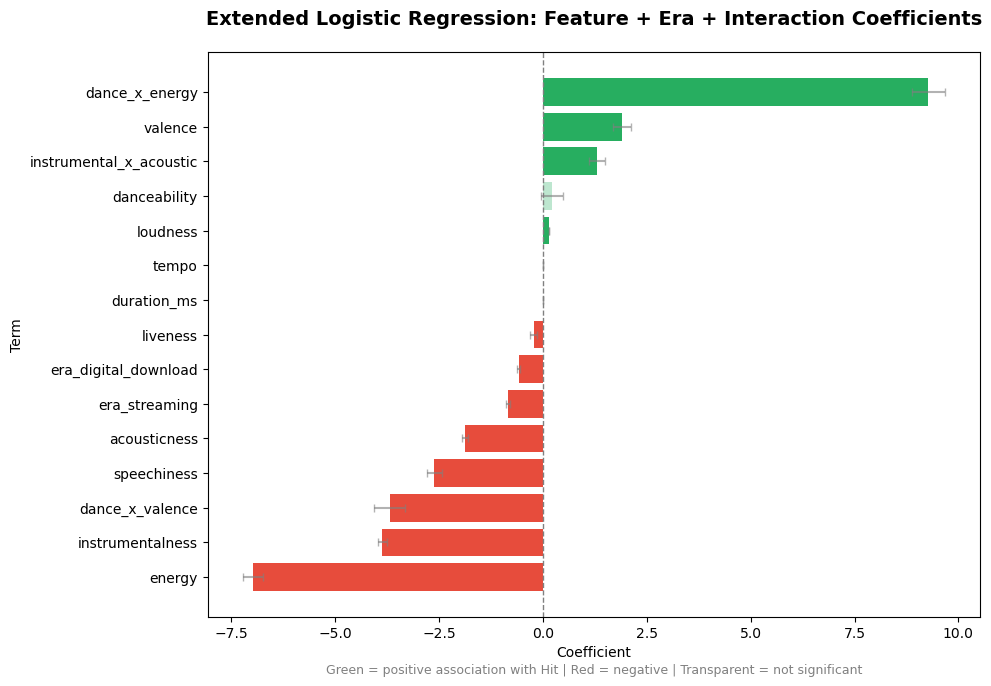

[SAVED] rq4_extended_coefficients.png


In [25]:
print("[STEP 15e] Extended Model -- Coefficient Plot")

plot_df_ext = coef_df_ext[coef_df_ext["term"] != "const"].copy()
plot_df_ext["direction_label"] = np.where(plot_df_ext["estimate"] > 0, "Positive", "Negative")
plot_df_ext = plot_df_ext.sort_values("estimate")

fig, ax = plt.subplots(figsize=(10, 7))
colors = plot_df_ext["direction_label"].map({"Positive": "#27AE60", "Negative": "#E74C3C"})
alphas = np.where(plot_df_ext["significant"] == "Yes", 1.0, 0.3)

bars = ax.barh(plot_df_ext["term"], plot_df_ext["estimate"], color=colors)
for bar, a in zip(bars, alphas):
    bar.set_alpha(a)
ax.errorbar(plot_df_ext["estimate"], plot_df_ext["term"], xerr=plot_df_ext["std_error"],
            fmt="none", ecolor="gray", capsize=3, alpha=0.6)
ax.axvline(0, color="gray", linestyle="--", linewidth=1)

ax.set_xlabel("Coefficient")
ax.set_ylabel("Term")
ax.text(0.5, -0.10, "Green = positive association with Hit | Red = negative | Transparent = not significant",
        transform=ax.transAxes, ha="center", fontsize=9, color="gray")
plt.tight_layout(rect=[0, 0, 1, 0.93])

pos = ax.get_position()
fig.suptitle("Extended Logistic Regression: Feature + Era + Interaction Coefficients",
             fontsize=14, fontweight="bold", y=0.97, x=(pos.x0 + pos.x1) / 2)
plt.savefig("../Data/rq4_extended_coefficients.png", dpi=120)
plt.show()
print('[SAVED] rq4_extended_coefficients.png')

[STEP 15f] Extended Model -- Evaluation on Test Set

Extended LR (Era + Interactions) Evaluation

Confusion Matrix:
            Actual 0   Actual 1
Pred 0          2787        792
Pred 1          1324       3319

Accuracy:    0.7426
Sensitivity: 0.8073  (Hit recall)
Specificity: 0.6779  (Flop recall)
AUC:         0.8171

--- Comparison to original 10-feature LR (Step 6) ---
Accuracy:    0.7426  (original: 0.7293)
Sensitivity: 0.8073  (original: 0.8095)
Specificity: 0.6779  (original: 0.6490)
AUC:         0.8171  (original: 0.8071)


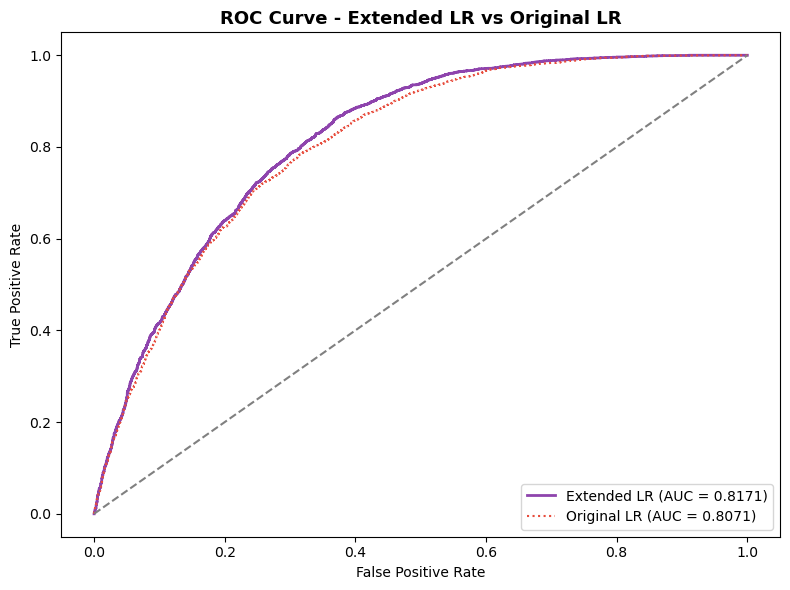

[SAVED] rq4_extended_roc.png


In [26]:
print("[STEP 15f] Extended Model -- Evaluation on Test Set")

ext_pred_prob = logit_model_ext.predict(X_test_ext_const)
ext_pred_class = (ext_pred_prob > 0.5).astype(int)
ext_results = evaluate_classifier("Extended LR (Era + Interactions)", y_test_ext, ext_pred_class, ext_pred_prob)

print("\n--- Comparison to original 10-feature LR (Step 6) ---")
print(f"Accuracy:    {ext_results['accuracy']:.4f}  (original: 0.7293)")
print(f"Sensitivity: {ext_results['sensitivity']:.4f}  (original: 0.8095)")
print(f"Specificity: {ext_results['specificity']:.4f}  (original: 0.6490)")
print(f"AUC:         {ext_results['auc']:.4f}  (original: 0.8071)")

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(ext_results["fpr"], ext_results["tpr"], color="#8E44AD", linewidth=2,
        label=f"Extended LR (AUC = {ext_results['auc']:.4f})")
ax.plot(lr_results["fpr"], lr_results["tpr"], color="#E74C3C", linewidth=1.5, linestyle=":",
        label=f"Original LR (AUC = {lr_results['auc']:.4f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
ax.set_title("ROC Curve - Extended LR vs Original LR", fontsize=13, fontweight="bold")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../Data/rq4_extended_roc.png", dpi=120)
plt.show()
print("[SAVED] rq4_extended_roc.png")

### Step 15 — Results

**Side-by-side against the original 10-feature model (Steps 3-6):**

| Metric | Original (10 features) | Extended (+ era, + interactions, 15 features) | Change |
|---|---|---|---|
| Pseudo R² | 0.2320 | 0.2544 | **+0.0224** |
| Accuracy | 0.7293 | 0.7426 | +0.0133 |
| Sensitivity | 0.8095 | 0.8073 | -0.0022 (essentially flat) |
| Specificity | 0.6490 | 0.6779 | **+0.0289** |
| AUC | 0.8071 | 0.8171 | +0.0100 |

**Three findings:**

1. Combining both extensions into one model beats the original baseline on every metric.
2. **Specificity — correctly identifying Flops — improves the most** (+0.0289): these 5 additional terms are particularly useful for recognizing when a song *won't* chart, not just for catching more Hits.
3. **`danceability`'s own coefficient loses significance again** in the extended model — its explanatory power runs mainly through its interaction with `energy` and `valence`, not as an isolated trait.

**Overall:** the 15-feature model moves AUC from 0.8071 to 0.8171 — closer to RF's 0.8666, though not matching it — and Pseudo R² from 23.2% to 25.4%. A real but modest gain: it doesn't overturn the core finding that audio features alone explain only part of what makes a Hit.